<a href="https://colab.research.google.com/github/Elijah2666/Machine-learning/blob/main/Engine_Health_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_engine = pd.read_csv('/content/engine_data.csv.zip')

In [4]:
df_engine.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [5]:
df_engine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [6]:
df_engine['Engine Condition'] = df_engine['Engine Condition'].astype('category')

In [7]:
df_engine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Engine rpm        19535 non-null  int64   
 1   Lub oil pressure  19535 non-null  float64 
 2   Fuel pressure     19535 non-null  float64 
 3   Coolant pressure  19535 non-null  float64 
 4   lub oil temp      19535 non-null  float64 
 5   Coolant temp      19535 non-null  float64 
 6   Engine Condition  19535 non-null  category
dtypes: category(1), float64(5), int64(1)
memory usage: 935.0 KB


In [8]:
df_engine.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


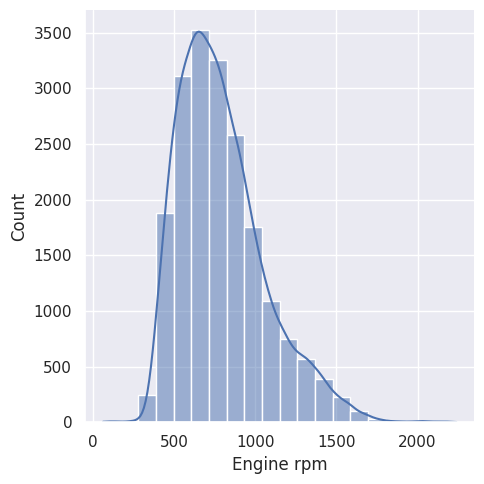

In [9]:
sns.displot(data=df_engine['Engine rpm'], bins= 20, kde= True)
plt.show()

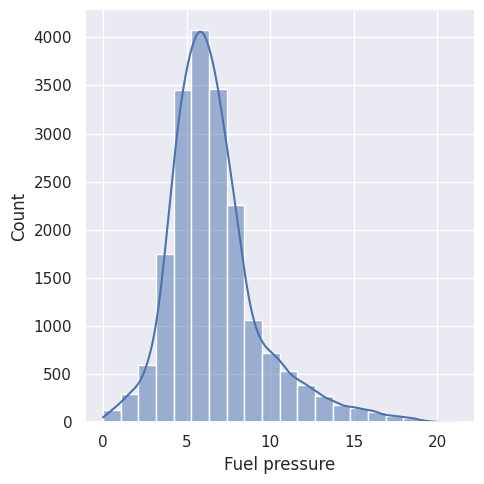

In [10]:
sns.displot(data=df_engine['Fuel pressure'], bins= 20, kde= True)
plt.show()

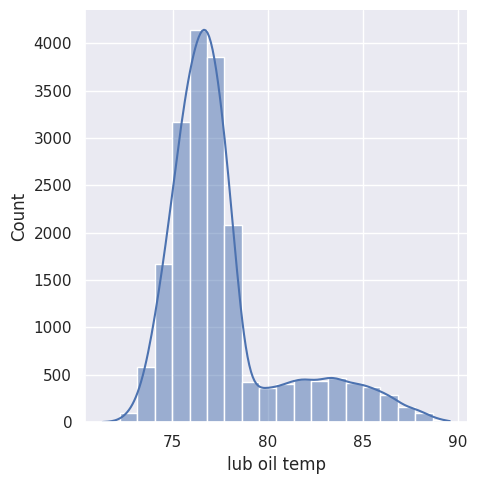

In [11]:
sns.displot(data=df_engine['lub oil temp'], bins= 20, kde= True)
plt.show()

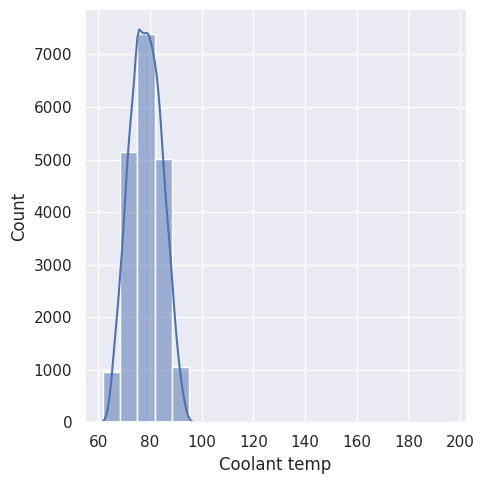

In [12]:
sns.displot(data=df_engine['Coolant temp'], bins= 20, kde= True)
plt.show()

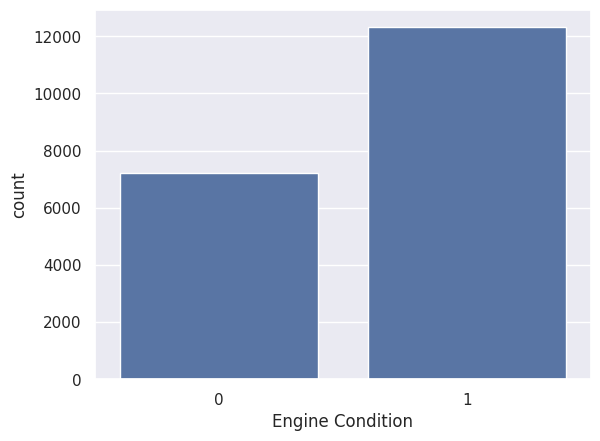

In [13]:
sns.countplot(x=df_engine['Engine Condition'])
plt.show()

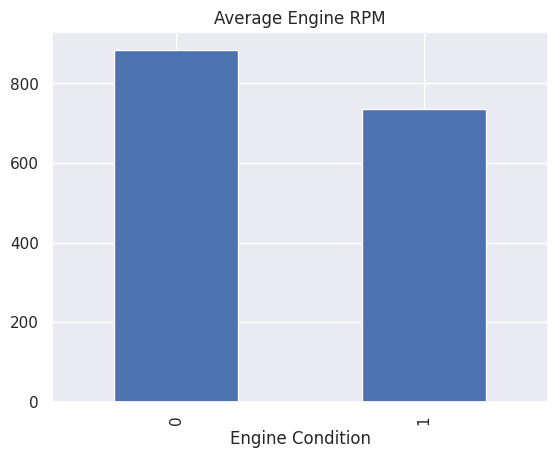

In [14]:
df_engine.groupby('Engine Condition')['Engine rpm'].mean().plot(kind='bar')
plt.title('Average Engine RPM')
plt.show()

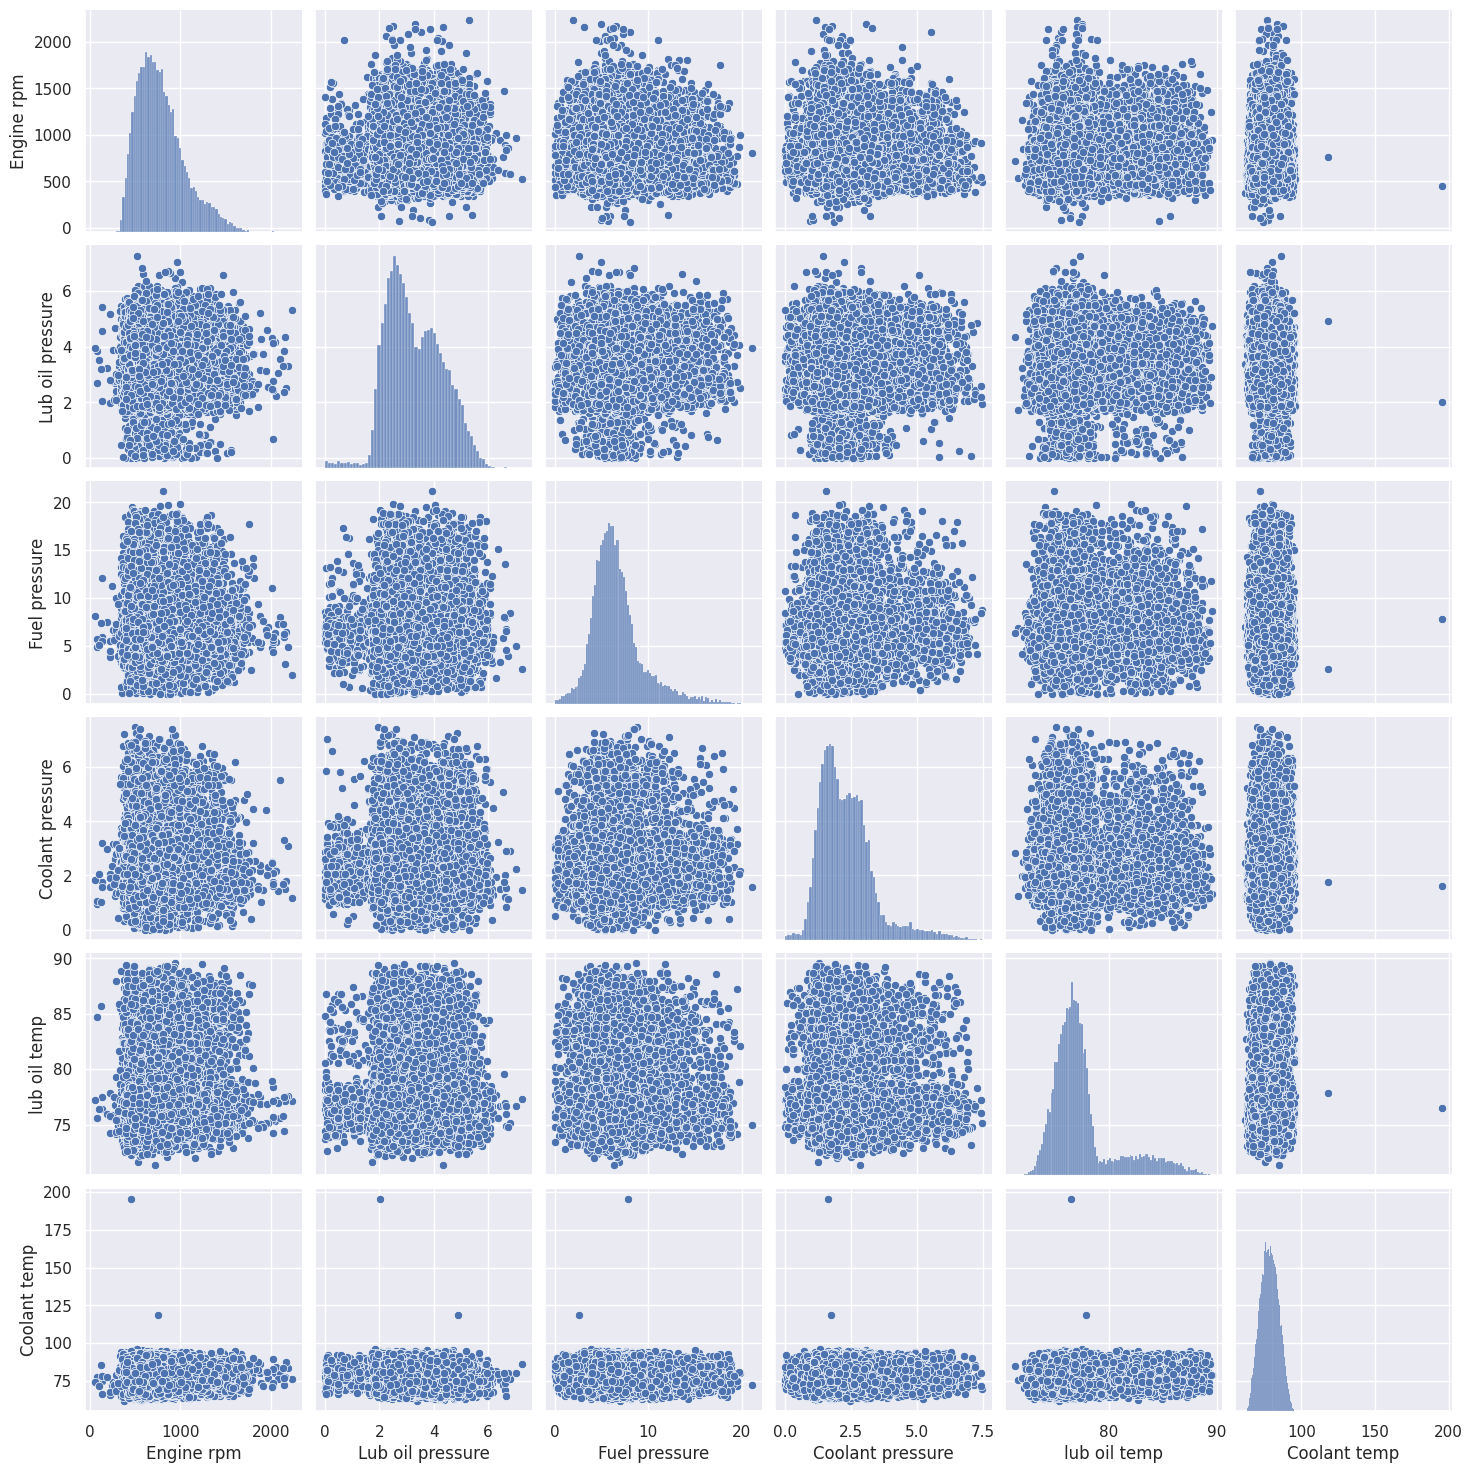

In [15]:
sns.pairplot(df_engine)

<Axes: >

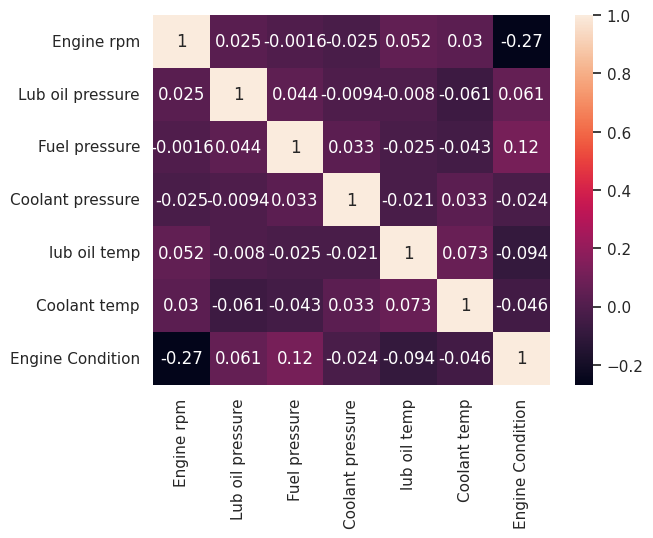

In [16]:
sns.heatmap(df_engine.corr(), annot=True)

<Axes: ylabel='Coolant temp'>

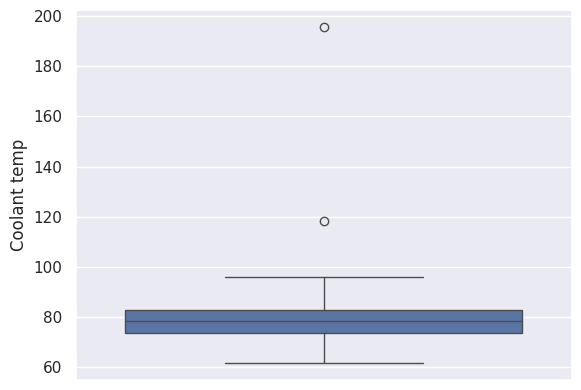

In [17]:
sns.boxplot(df_engine['Coolant temp'])

<Axes: ylabel='lub oil temp'>

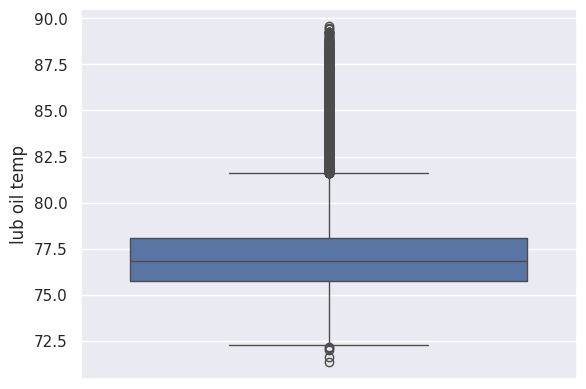

In [18]:
sns.boxplot(df_engine['lub oil temp'])

<Axes: ylabel='Lub oil pressure'>

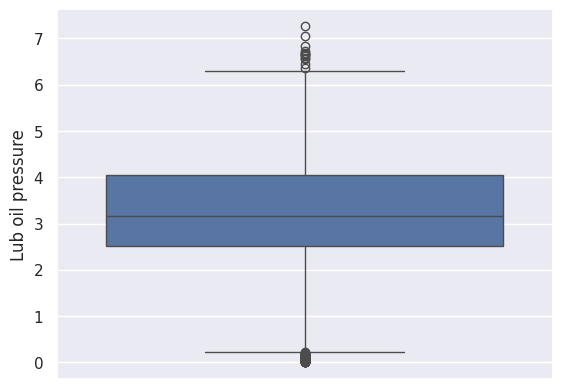

In [19]:
sns.boxplot(df_engine['Lub oil pressure'])


<Axes: ylabel='Coolant pressure'>

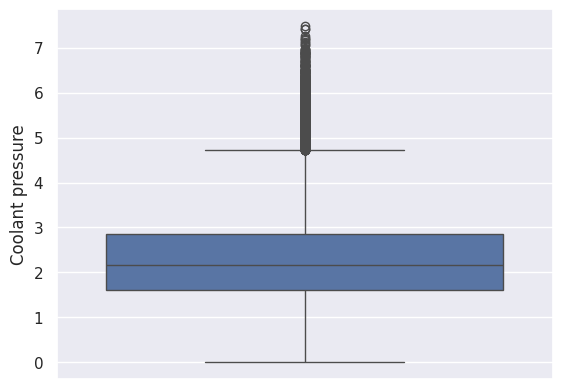

In [20]:
sns.boxplot(df_engine['Coolant pressure'])

In [21]:
for i in ['Engine rpm', 'Lub oil pressure','Fuel pressure', 'Coolant pressure','lub oil temp']:
    percentile25 = df_engine[i].quantile(0.25)
    percentile75 = df_engine[i].quantile(0.75)

    iqr = percentile75 - percentile25

    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr
    oulier_count=len(df_engine[df_engine[i]>upper_limit])+len(df_engine[df_engine[i]<lower_limit])
    print("The no. of outliers in", i, 'is', oulier_count)
    df_engine[i] = np.where(
    df_engine[i] > upper_limit, upper_limit, np.where( df_engine[i] < lower_limit, lower_limit, df_engine[i]))

The no. of outliers in Engine rpm is 464
The no. of outliers in Lub oil pressure is 66
The no. of outliers in Fuel pressure is 1135
The no. of outliers in Coolant pressure is 785
The no. of outliers in lub oil temp is 2617


In [22]:
upper_limit_cooltemp = df_engine['Coolant temp'].mean() + 3*df_engine['Coolant temp'].std()
lower_limit_cooltemp = df_engine['Coolant temp'].mean() - 3*df_engine['Coolant temp'].std()
df_engine['Coolant temp'] = np.where(
    df_engine['Coolant temp']>upper_limit_cooltemp,
    upper_limit_cooltemp,
    np.where(
        df_engine['Coolant temp']<lower_limit_cooltemp,
        lower_limit_cooltemp,
        df_engine['Coolant temp']
    )
)

<Axes: ylabel='lub oil temp'>

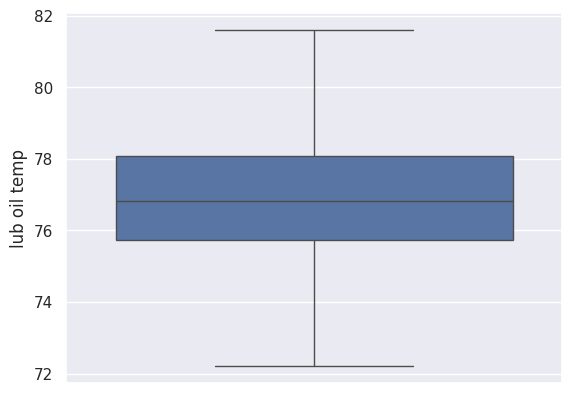

In [23]:
sns.boxplot(df_engine['lub oil temp'])

<Axes: ylabel='Coolant temp'>

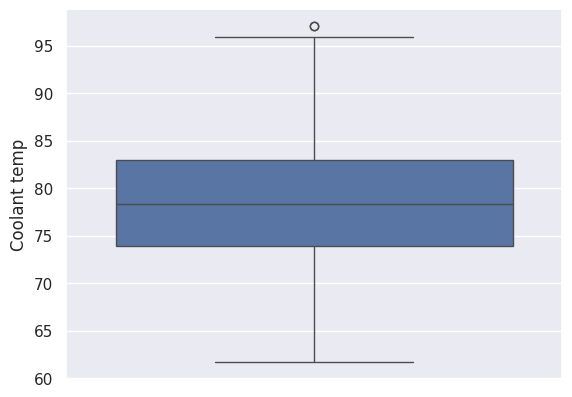

In [24]:
sns.boxplot(df_engine['Coolant temp'])

<Axes: ylabel='Lub oil pressure'>

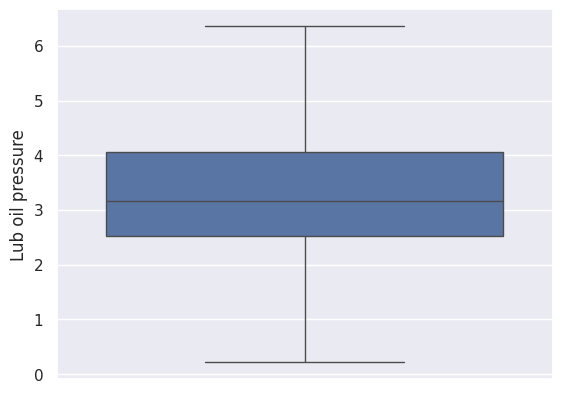

In [25]:
sns.boxplot(df_engine['Lub oil pressure'])

In [26]:
X = df_engine.drop(['Engine Condition'], axis=1)
Y = df_engine['Engine Condition']


In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state = 42, test_size = 0.25)
x_train.shape, x_test.shape

((14651, 6), (4884, 6))

In [28]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

In [29]:
x_train_scaled[0:5]

array([[-0.22239222, -2.7488954 ,  0.29187198,  0.30050099, -0.47063203,
        -1.1585091 ],
       [ 1.05580517,  1.43100116, -0.03576588,  0.54098826, -1.16842008,
        -1.06111234],
       [-0.28436543, -0.73148714,  0.12720982, -0.67954471,  0.04907308,
         0.72943356],
       [ 0.38571987, -1.07324799, -1.07598605,  0.51824331,  1.90840975,
         1.65176987],
       [-1.11325707,  0.36352408, -1.00524377, -1.54645915,  0.05501233,
        -0.0969859 ]])

In [30]:
x_train_scaled=pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [31]:
x_train_scaled.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.222392,-2.748895,0.291872,0.300501,-0.470632,-1.158509
1,1.055805,1.431001,-0.035766,0.540988,-1.168420,-1.061112
2,-0.284365,-0.731487,0.127210,-0.679545,0.049073,0.729434
3,0.385720,-1.073248,-1.075986,0.518243,1.908410,1.651770
4,-1.113257,0.363524,-1.005244,-1.546459,0.055012,-0.096986


In [32]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression()
LR_model.fit(x_train_scaled, y_train)

LogisticRegression()

In [33]:
y_pred_LR = LR_model.predict(x_test_scaled)
from sklearn.metrics import confusion_matrix, accuracy_score
print('Acuuracy Score: {}'.format((accuracy_score(y_test, y_pred_LR) * 100)))

Acuuracy Score: 65.06961506961507


In [35]:
from sklearn.ensemble import RandomForestClassifier
RFC_model = RandomForestClassifier()
RFC_model.fit(x_train_scaled, y_train)
y_pred_RFC = RFC_model.predict(x_test_scaled)

from sklearn import metrics

print('Acuuracy Score: {}'.format((accuracy_score(y_test, y_pred_RFC) * 100)))

Acuuracy Score: 64.31203931203932


In [36]:
RFC2_model = RandomForestClassifier(criterion= 'entropy', max_depth= 8, min_samples_split= 2, n_estimators= 150)
RFC2_model.fit(x_train_scaled, y_train)
y_pred_RFC2 = RFC2_model.predict(x_test_scaled)

from sklearn import metrics

print('Acuuracy Score: {}'.format((accuracy_score(y_test, y_pred_RFC2) * 100)))

Acuuracy Score: 65.9090909090909


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [38]:
cm = confusion_matrix(y_test, y_pred_RFC2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=[False, True])

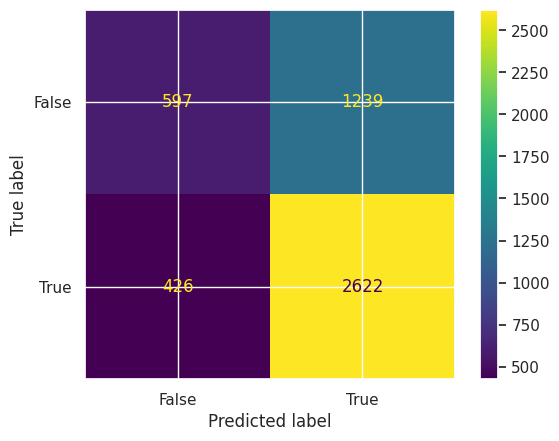

In [39]:
disp.plot()
plt.show()

In [40]:
F1_score = metrics.f1_score(y_test, y_pred_RFC2)
F1_score

0.7590099869735129